In [1]:
import os
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [5]:
MODELS_DIR = "../models/pu-demand/"

results = []

for model_name in os.listdir(MODELS_DIR):

    result_path = os.path.join(
        MODELS_DIR,
        model_name,
        "results.pkl"
    )

    if os.path.exists(result_path):

        with open(result_path, "rb") as f:
            metrics = pickle.load(f)

        metrics["Model"] = model_name

        results.append(metrics)

df = pd.DataFrame(results)

df.head()

,best_r2,best_params,rmse_mean,rmse_std,r2_mean,r2_std,rae_mean,rae_std,test_metrics,Model
0,0.899440,"{'n_estimators': 100, 'learning_rate': 0.1, 'm...",23.948397,0.220056,0.899440,0.001722,0.262594,0.001701,"{'RMSE': 24.02143530953426, 'R2': 0.8975853073...",lightgbm
1,NaN,NaN,47.556358,0.192312,0.604173,0.001773,0.551006,0.001606,"{'RMSE': 47.47550105656943, 'R2': 0.5999599499...",linear_regression
2,0.814802,"{'n_estimators': 50, 'max_depth': 20, 'min_sam...",32.494830,0.536775,0.814802,0.006697,0.379667,0.007309,"{'RMSE': 31.61845258090105, 'R2': 0.8225624296...",random_forest
3,0.874792,"{'n_estimators': 100, 'max_depth': 8, 'learnin...",26.695195,1.105722,0.874792,0.010742,0.268824,0.007023,"{'RMSE': 27.04336633917569, 'R2': 0.8701966404...",xgboost


In [7]:
columns = [
    "Model",
    "rmse_mean",
    "rmse_std",
    "r2_mean",
    "r2_std",
    "rae_mean",
    "rae_std"
]

df = df[columns]

df.sort_values(
    by="r2_mean",
    ascending=False,
    inplace=True
)

df.reset_index(drop=True, inplace=True)

df.to_csv(
    "../results/results_pu_summary.csv",
    index=False
)

df

,Model,rmse_mean,rmse_std,r2_mean,r2_std,rae_mean,rae_std
0,lightgbm,23.948397,0.220056,0.899440,0.001722,0.262594,0.001701
1,xgboost,26.695195,1.105722,0.874792,0.010742,0.268824,0.007023
2,random_forest,32.494830,0.536775,0.814802,0.006697,0.379667,0.007309
3,linear_regression,47.556358,0.192312,0.604173,0.001773,0.551006,0.001606


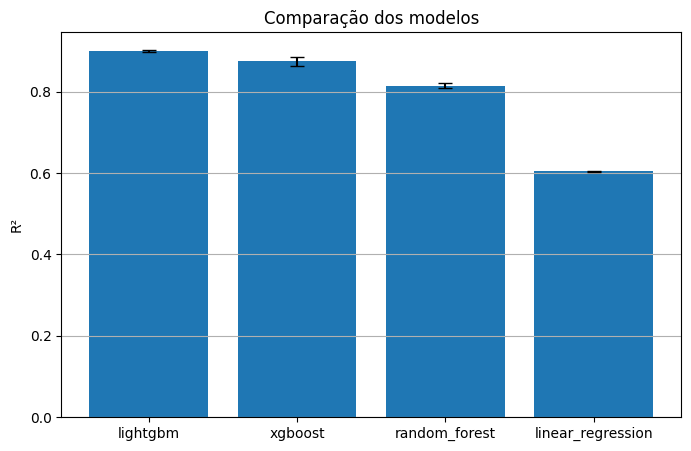

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["r2_mean"],
    yerr=df["r2_std"],
    capsize=5
)

plt.ylabel("R²")
plt.title("Comparação dos modelos")
plt.grid(axis="y")

plt.show()

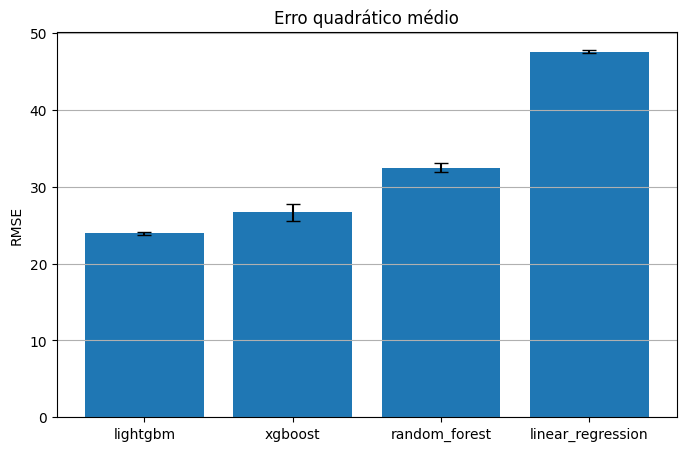

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["rmse_mean"],
    yerr=df["rmse_std"],
    capsize=5
)

plt.ylabel("RMSE")
plt.title("Erro quadrático médio")
plt.grid(axis="y")

plt.show()

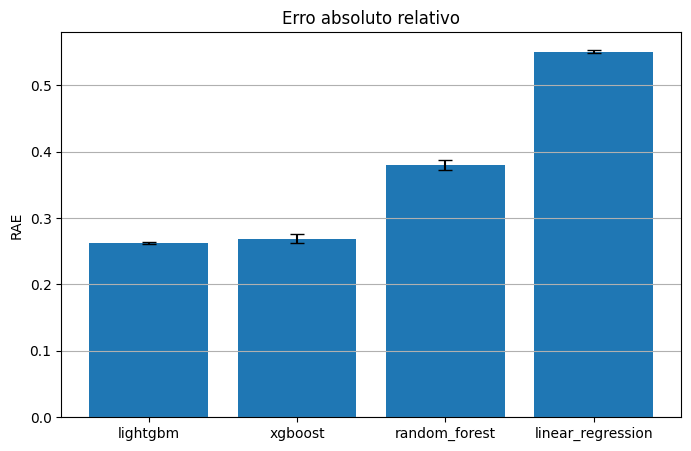

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Model"],
    df["rae_mean"],
    yerr=df["rae_std"],
    capsize=5
)

plt.ylabel("RAE")
plt.title("Erro absoluto relativo")
plt.grid(axis="y")

plt.show()

In [11]:
ranking = df.sort_values(
    by="r2_mean",
    ascending=False
)

ranking[[
    "Model",
    "r2_mean",
    "rmse_mean",
    "rae_mean"
]]

,Model,r2_mean,rmse_mean,rae_mean
0,lightgbm,0.899440,23.948397,0.262594
1,xgboost,0.874792,26.695195,0.268824
2,random_forest,0.814802,32.494830,0.379667
3,linear_regression,0.604173,47.556358,0.551006


In [12]:
ranking = df.copy()

ranking["Score"] = (
      ranking["r2_mean"]
    - ranking["rmse_mean"] / ranking["rmse_mean"].max()
    - ranking["rae_mean"]
)

ranking = ranking.sort_values(
    by="Score",
    ascending=False
)

ranking[[
    "Model",
    "Score"
]]

,Model,Score
0,lightgbm,0.133267
1,xgboost,0.044629
2,random_forest,-0.248156
3,linear_regression,-0.946833


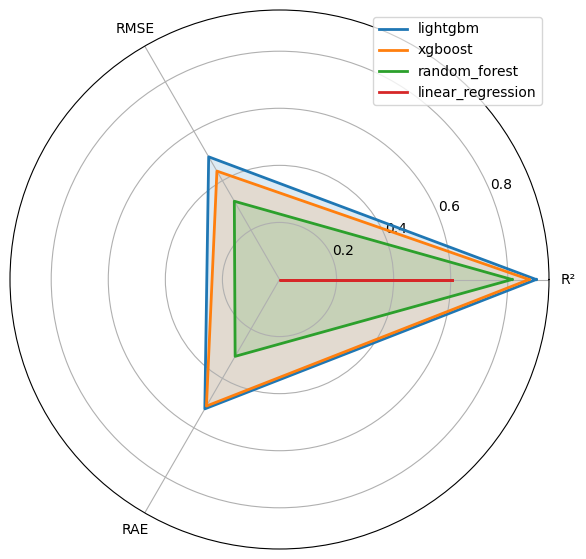

In [13]:
from math import pi

metrics = ["r2_mean", "rmse_mean", "rae_mean"]

plot = df.copy()

plot["rmse_mean"] = 1 - plot["rmse_mean"]/plot["rmse_mean"].max()
plot["rae_mean"] = 1 - plot["rae_mean"]/plot["rae_mean"].max()

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
)

angles = np.concatenate([angles, [angles[0]]])
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for _, row in plot.iterrows():

    values = [
        row["r2_mean"],
        row["rmse_mean"],
        row["rae_mean"]
    ]

    values.append(values[0])

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["R²", "RMSE", "RAE"])

plt.legend()
plt.show()